# TITLE: Customer Churn Prediction

> INTRODUCTION


Customer churn is a critical problem in the telecommunications industry, where companies aim to retain existing customers rather than acquire new ones due to the high cost of customer acquisition. This project focuses on building a machine learning model that predicts whether a customer is likely to churn based on their demographic information, service usage, and account details.

The objective is to identify key factors influencing churn and develop a predictive model that can assist the company in making proactive retention decisions.


> ABOUT DATASET


The dataset used in this project was obtained from Kaggle [here for more info](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) and contains information about customers from a telecommunications company. It consists of 7,043 rows and 21 columns, where each row represents a single customer record.
 ## Column description
---  ------            --------------  -----  
* customerID: Unique identifier assigned to each customer.
* gender: Customer’s gender (Male/Female).
* SeniorCitizen: Indicates if the customer is a senior citizen (1 = Yes, 0 = No).
* Partner: Whether the customer has a partner (Yes/No).
* Dependents: Whether the customer has dependents (Yes/No).
* tenure: Number of months the customer has stayed with the company.
* PhoneService: Whether the customer has phone service (Yes/No).
* MultipleLines: Whether the customer has multiple phone lines (Yes/No/No phone service).
* InternetService: Type of internet service (DSL, Fiber optic, No).
* OnlineSecurity: Whether the customer has online security service (Yes/No/No internet service).
* OnlineBackup: Whether the customer has online backup service (Yes/No/No internet service).
* DeviceProtection: Whether the customer has device protection (Yes/No/No internet service).
* TechSupport: Whether the customer has tech support service (Yes/No/No internet service).
* StreamingTV: Whether the customer streams TV (Yes/No/No internet service).
* StreamingMovies: Whether the customer streams movies (Yes/No/No internet service).
* Contract: Type of contract (Month-to-month, One year, Two year).
* PaperlessBilling: Whether the customer uses paperless billing (Yes/No).
* PaymentMethod: Customer’s payment method ( Electronic check, Mailed check, Bank transfer(automatic), Credit card(automatic))
* MonthlyCharges: Amount charged to the customer monthly.
* TotalCharges: Total amount charged to the customer over time.
* Churn: Indicates whether the customer has left the company (Yes = Churned, No = Retained).

 ## METHODOLOGY
---  ------            --------------  -----  

this section follows a step by step process for predicting customer churn
1) loading the data
2) Exploratory analysis
3) Data cleaning and Feature Engineering
4) Preprocessing and Model
5) Results
6) Conclusion and Recommendation

## Step 1: Loading the dataset

In [180]:
# Import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import  train_test_split,KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score, roc_curve, accuracy_score, recall_score, precision_score
seed = 123

In [181]:
# Load dataset and view fist 5 rows
data =  pd.read_csv(r'c:\Users\BLESSING\Desktop\PYTHON\WA_Fn-UseC_-Telco-Customer-Churn.csv')
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 2: Exploratory Data Analysis

In [182]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


* The dataset has 7043 entries and 21 columns. There are no convectional missing values in the dataset.
* TotalCharges will have to be changed to float data type
* Senior Cittizen will have to be changed to object data type
* Categorical columns need to be encoded

In [183]:
data.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


* Univariant analysis

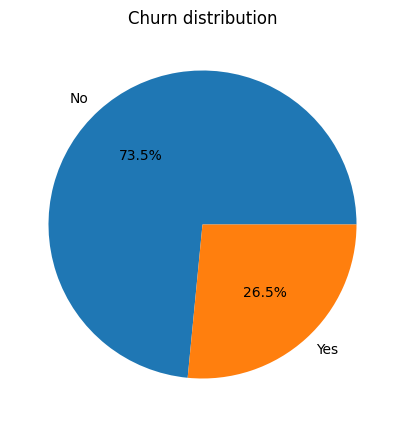

In [184]:
# Churn distribution

plt.figure(figsize=(10,5))

plt.pie(data['Churn'].value_counts().values,labels= data['Churn'].value_counts().index, autopct='%1.1f%%')
plt.title('Churn distribution')
plt.show()




* 73.5% of customers didnt churn. It is important to note that the dataset is imbalanced, with a higher proportion of customers who did not churn compared to those who churned. This imbalance should be considered and handled with balancing technique as it can affect model performance.


       SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    7043.000000  7043.000000     7043.000000   7032.000000
mean        0.162147    32.371149       64.761692   2283.300441
std         0.368612    24.559481       30.090047   2266.771362
min         0.000000     0.000000       18.250000     18.800000
25%         0.000000     9.000000       35.500000    401.450000
50%         0.000000    29.000000       70.350000   1397.475000
75%         0.000000    55.000000       89.850000   3794.737500
max         1.000000    72.000000      118.750000   8684.800000


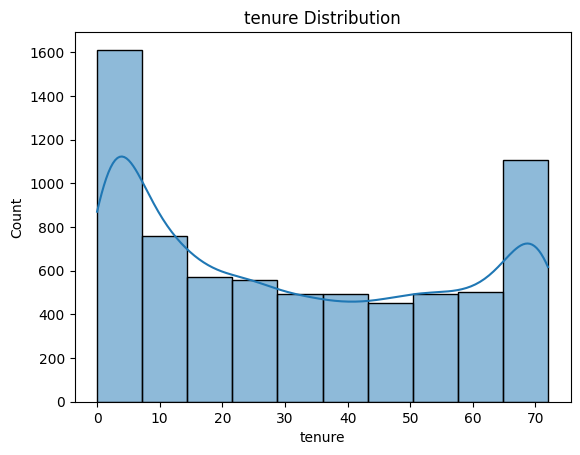

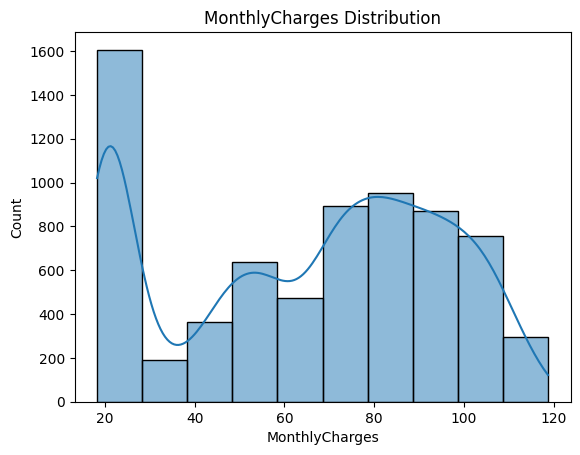

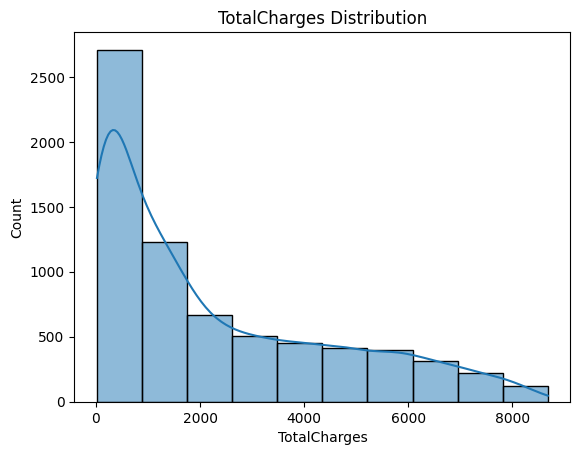

In [185]:
# Distribution of numerical columns


data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')     # Convert TotalCharges to float, any non-numeric value is treated as a missing value

print(data.describe())

nums =['tenure', 'MonthlyCharges', 'TotalCharges']
for num in nums:
    figure = figsize=(10,5)
    sns.histplot(data[num], bins=10, kde=True)
    plt.title(f'{num} Distribution')
    plt.show()


    

> Observation
* The tenure distribution shows a bimodal pattern, with a high concentration of customers in the 0–5 months range and another peak around 65–72 months.

    This indicates two dominant customer groups:
    - New customers (low tenure)
    - Long-term loyal customers (high tenure)

    There is also a noticeable decline in customer count in the mid-tenure range, suggesting that customers are more likely to leave early in their lifecycle before becoming long-term users.

* MonthlyCharges distribution shows that prices are not evenly distributed, indicating different pricing ranges. Many customers pay low charges(~20 -30), while another cluster pay high charge(~70 - 100), with a few customers in the middle who pay(~30 -50).This suggests that customers are segmented based on service level which may influence churn behaviour.

* The TotalCharge distribution is right-skewed, with most customers having low cumulative spending. This suggests  a large portion of customers are new or have short tenure, while a small portion of long-term customers contibute to higher charges.

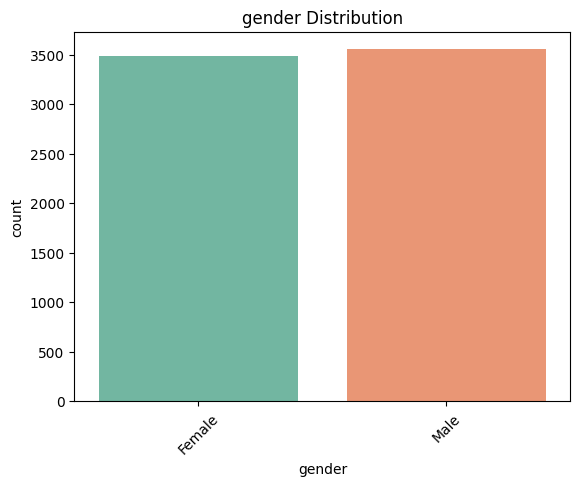

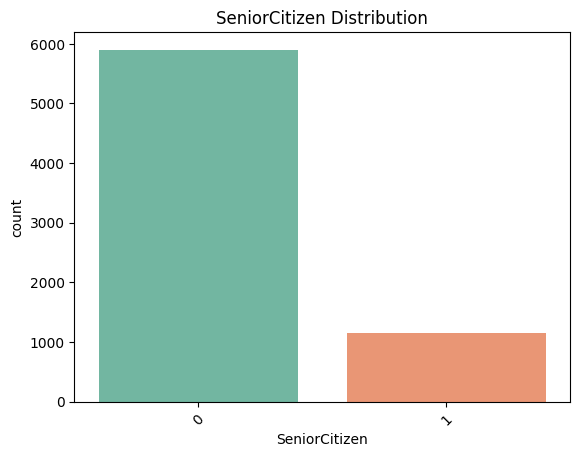

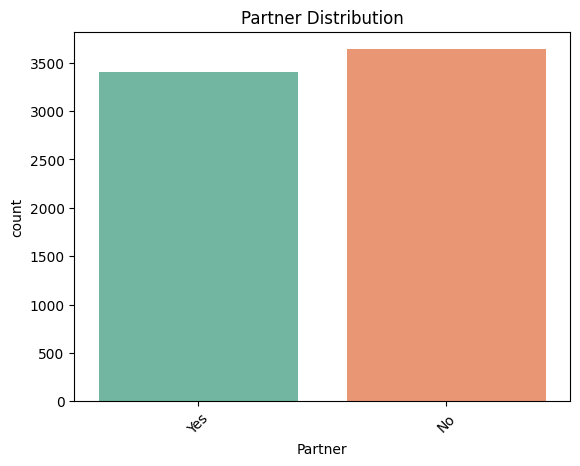

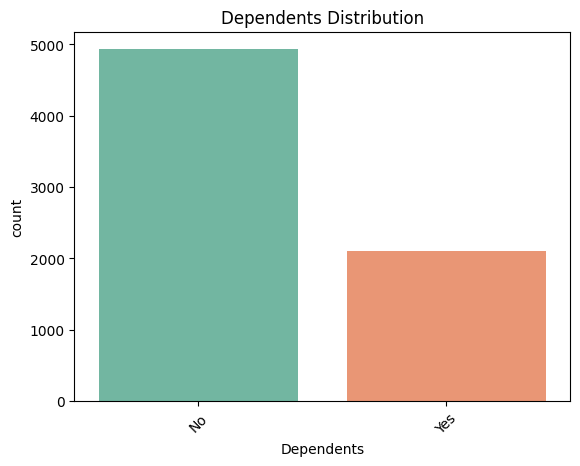

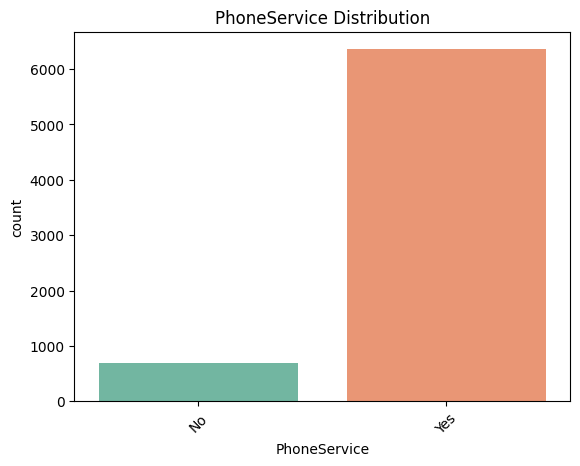

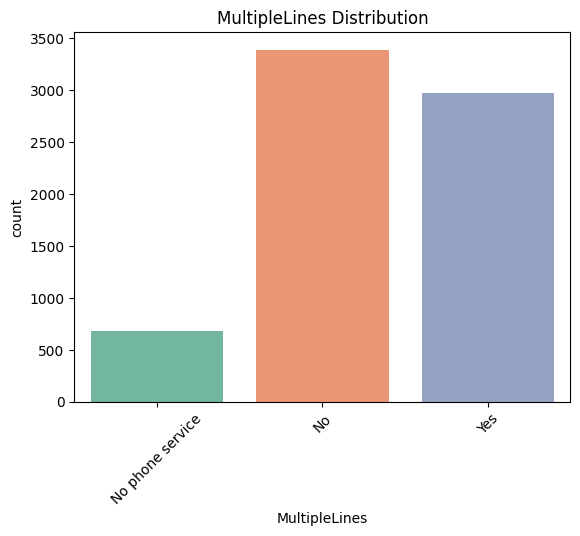

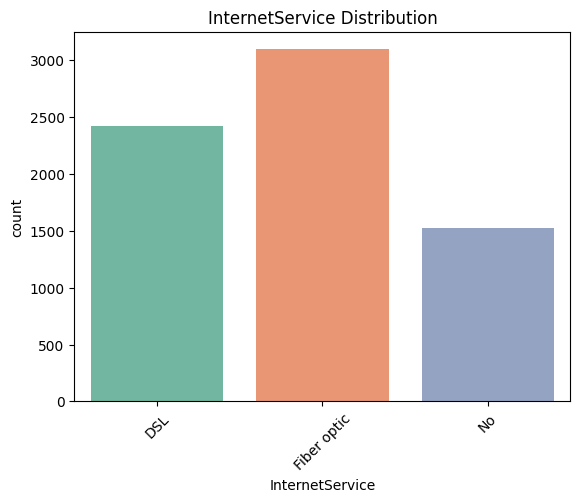

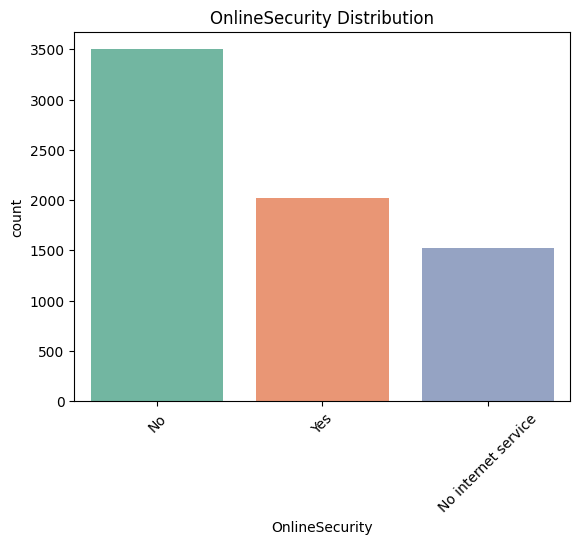

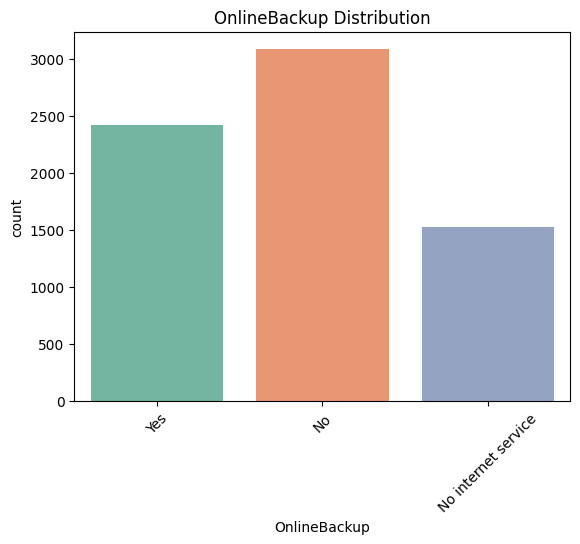

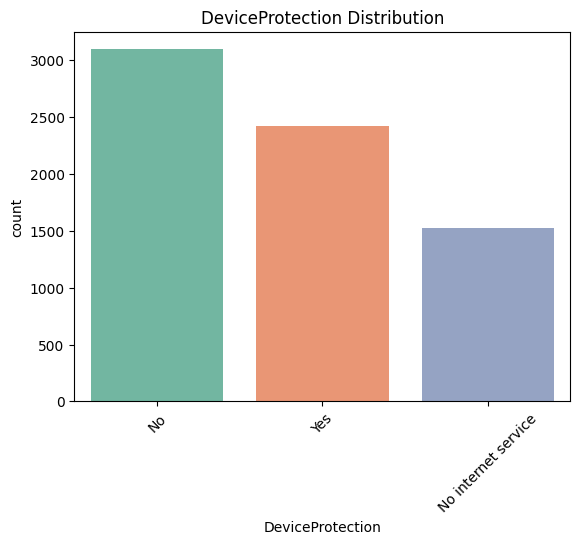

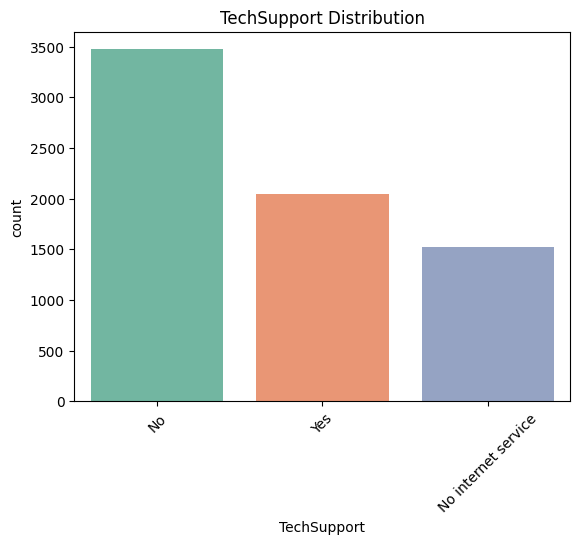

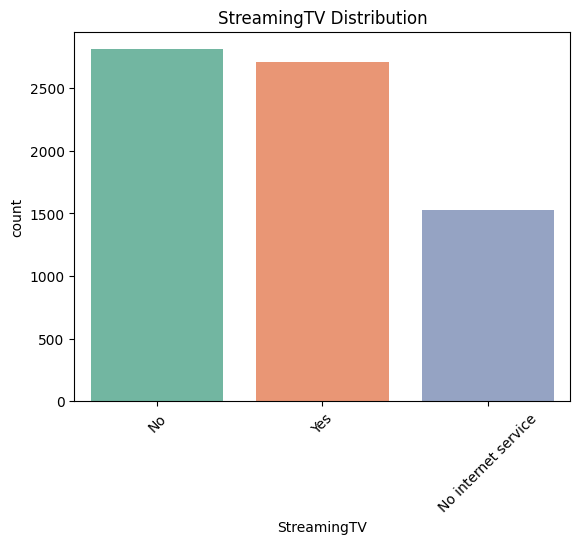

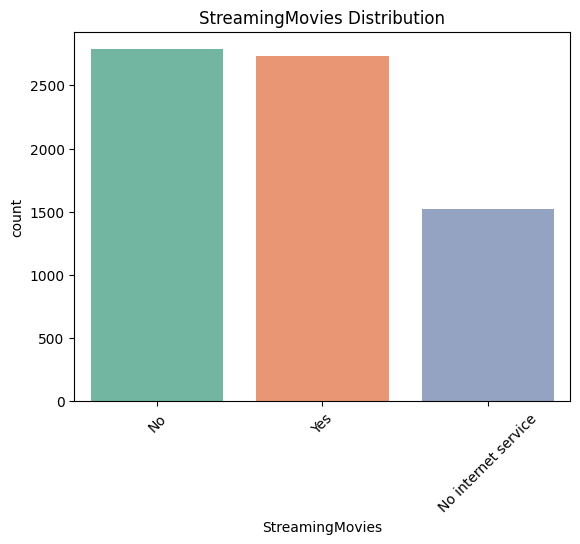

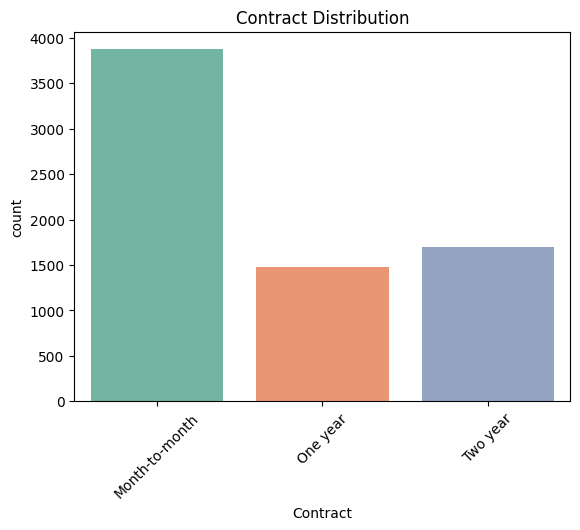

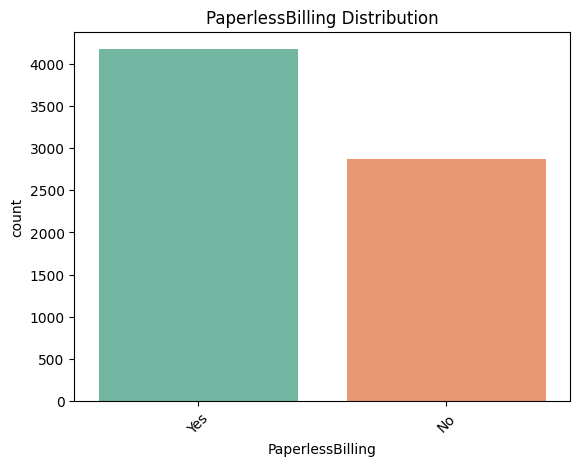

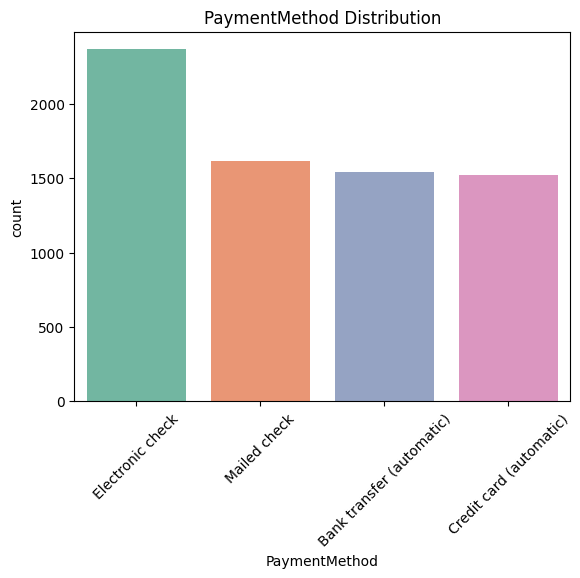

In [186]:
# Distribution of categorical columns

data['SeniorCitizen'] = data['SeniorCitizen'].astype('object')  # Convert SeniorCitizen to object type for categorical analysis


cats = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
        'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod']


for cat in cats:
    sns.countplot(x=cat, data=data, palette='Set2', hue =cat, legend=False)
    plt.title(f'{cat} Distribution')
    plt.xticks(rotation=45)
    plt.show()

* Multivariant analysis (ANALYSIS BY CHURN)

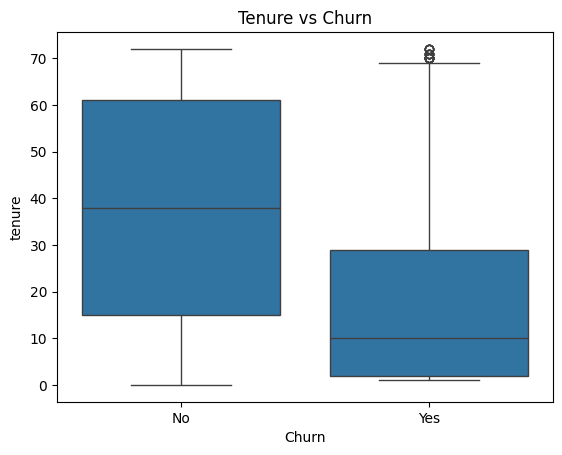

In [187]:
#'Tenure vs Churn'

sns.boxplot(x='Churn', y='tenure', data=data)
plt.title('Tenure vs Churn')
plt.show()

* Customers who churn tend to have lower tenure compared to those who remain. This indicates that newer customers are more likely to churn, highlighting the importance of early customer engagement.

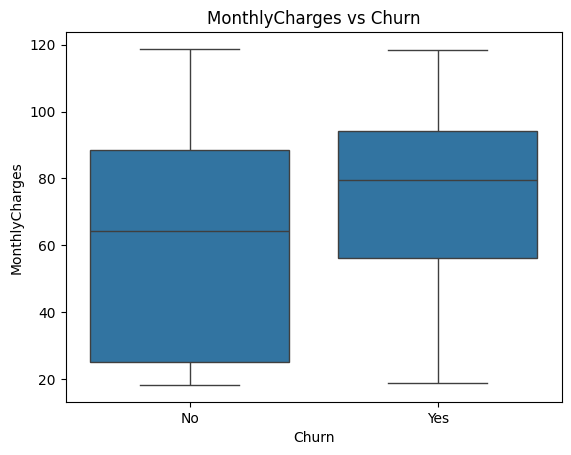

In [188]:
#'MonthlyCharges vs Churn'

sns.boxplot(x='Churn', y='MonthlyCharges', data=data)
plt.title('MonthlyCharges vs Churn')
plt.show()

* Customers with higher monthly charges tend to churn more frequently. This suggests that pricing may play a significant role in customer retention.

In [189]:
numeric_df = data.select_dtypes(include=['float64', 'int64'])

numeric_df.corr()

,tenure,MonthlyCharges,TotalCharges
tenure,1.00000,0.247900,0.825880
MonthlyCharges,0.24790,1.000000,0.651065
TotalCharges,0.82588,0.651065,1.000000


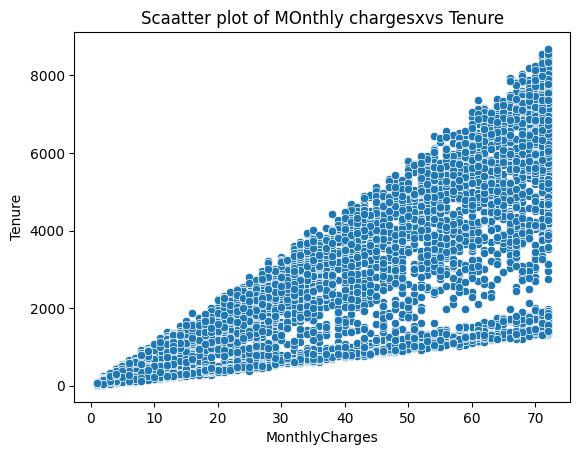

In [190]:
sns.scatterplot(y = 'TotalCharges', x= 'tenure', data= data )
plt.title('Scaatter plot of MOnthly chargesxvs Tenure')
plt.xlabel('MonthlyCharges')
plt.ylabel('Tenure')
plt.show()

Churn          No        Yes
gender                      
Female  73.079128  26.920872
Male    73.839662  26.160338


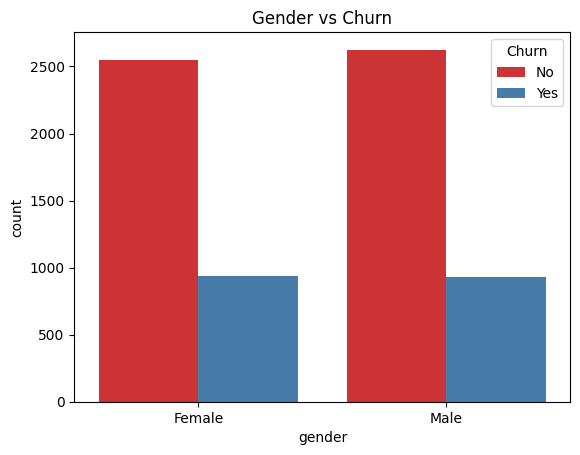

In [191]:
# Gender vs Churn
print(pd.crosstab(data['gender'], data['Churn'], normalize='index') * 100)


sns.countplot(x=data['gender'], hue=data['Churn'], palette= 'Set1')
plt.title('Gender vs Churn')
plt.show()

* The gender distribution of customers is balanced, further analysis shows that churn rates are similar across both groups. This suggests that gender is not a significant factor influencing customer churn.

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


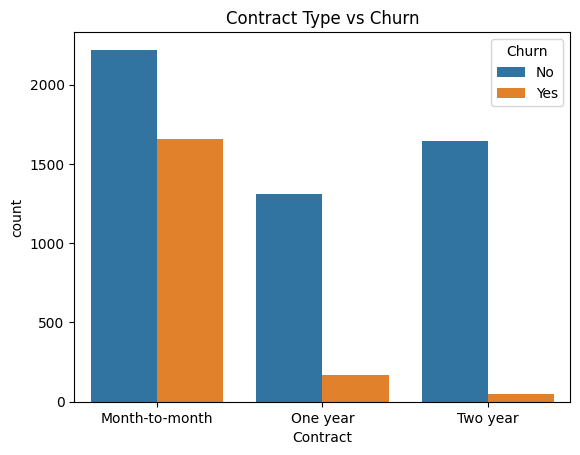

In [192]:
# contract type vs churn

# Percentage table
print(pd.crosstab(data['Contract'], data['Churn'], normalize='index') * 100)


# Visualization
sns.countplot(x='Contract', hue='Churn', data=data)
plt.title('Contract Type vs Churn')
plt.show()

* Customers on month-to-month contracts show the highest churn rate, while those on one-year and two-year contracts have significantly lower churn rates. This suggests that long-term contracts improve customer retention, and customers without long term contracts are more susceptible to competitor offers and service dissatisfaction.

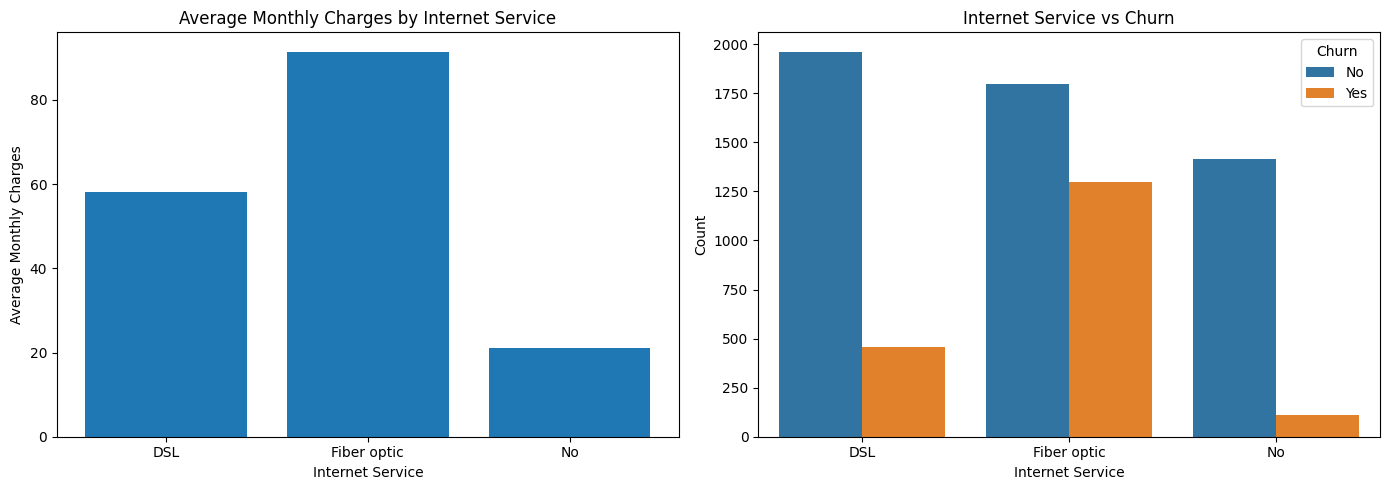

In [193]:
# Internet Service vs Churn

fig, axes = plt.subplots(1,2, figsize=(14,5))

g =  data.groupby('InternetService')['MonthlyCharges'].mean()

axes[0].bar(g.index, g.values)
axes[0].set_title('Average Monthly Charges by Internet Service')
axes[0].set_xlabel('Internet Service')
axes[0].set_ylabel('Average Monthly Charges')

sns.countplot(x='InternetService', hue='Churn', data=data)
axes[1].set_title('Internet Service vs Churn')
axes[1].set_xlabel('Internet Service')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()


* Fiber optic is seen to cost more in terms of monthly chrages, and is also shows that customer using the Fiber optic plan twice a higher churn rate compared to DSL users and those without internet service. This may indicate dissatisfaction with cost, service expectations, or better competitive fibre offerings in the market

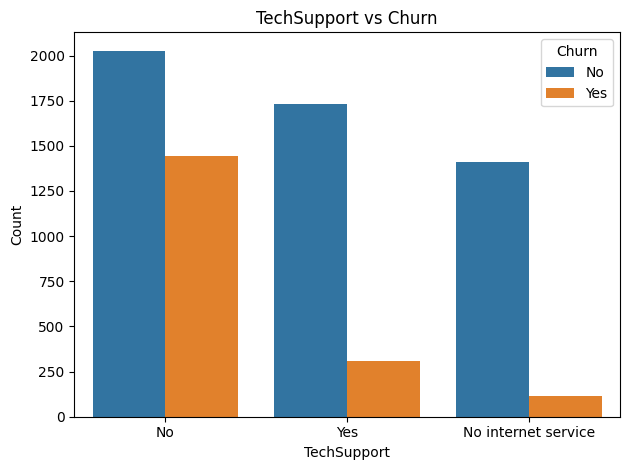

In [194]:
# TechSupport vs Churn

sns.countplot(x='TechSupport', hue='Churn', data=data)
plt.title('TechSupport vs Churn')
plt.xlabel('TechSupport')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

* Customers without tech support are significantly more likely to churn compared to those who have access to support services. This suggests that customer support plays a key role in retention.

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


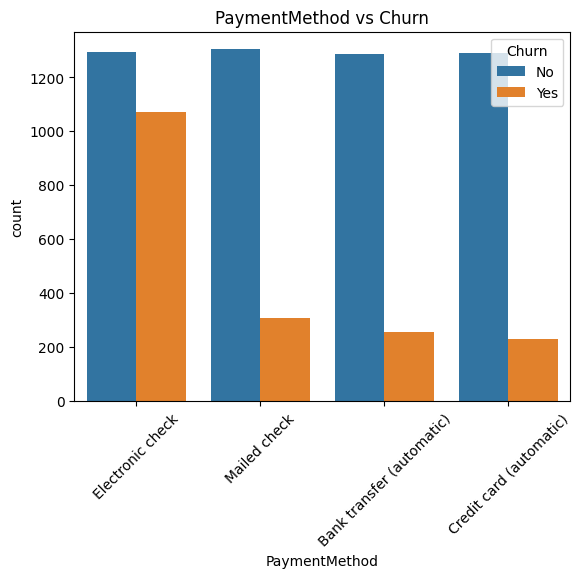

In [195]:
# PaymentMethod vs Churn
print(pd.crosstab(data['PaymentMethod'], data['Churn'], normalize='index') * 100)


# Visualization
sns.countplot(x='PaymentMethod', hue='Churn', data=data)
plt.title('PaymentMethod vs Churn')
plt.xticks(rotation=45)
plt.show()

* Customers using electronic check as their payment method exhibit higher churn rates compared to other payment methods. This may reflect differences in customer engagement or payment convenience.

## Step 3 Data cleaning and Feature engineering

In [196]:
#handling misiing values

data.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [197]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [198]:
# Filter missing values
data[data['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [199]:
data= data.dropna(subset=['TotalCharges'])

* Missing values were observed in the TotalCharges column. Further investigation revealed that these values correspond to customers with zero tenure, indicating that they are new customers who have not yet been billed. Therefore, the missing values were replaced with 0 to reflect the true state of their total charges.

In [200]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Step4: Preprocessing and Models

In [201]:
data.select_dtypes(include='object').columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'Churn'],
      dtype='object')

In [202]:
# Spliting features and target 


data = data.drop(columns='customerID', axis=1)        #drop irrelevant columns

x = data.drop(columns='Churn', axis =1)
y = data['Churn'].map({"Yes": 1, "No": 0})   # Encode target



In [203]:
# Split dataset by 80/20
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, stratify=y, random_state=seed)

In [204]:
# Ecnoding categorical variables
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)


In [205]:
# standardize features for Linear regression and Knn model
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [206]:
#KNN
all_cv_score = []
k_values = range(1, 21)

for k in (k_values):
    knn = KNeighborsClassifier(n_neighbors= k)
    kf = KFold(n_splits=5, shuffle=True, random_state=seed)
  
    cv_score = cross_val_score(knn, X_train_scaled, y_train, cv=kf, scoring='f1')
    all_cv_score.append(cv_score.mean())



best_k = k_values[np.argmax(all_cv_score)]
print(f'The best k value for knn: {best_k}, with a cv accuracy of {max(all_cv_score)}')


# KNN prediction
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)
knn_pred =  knn.predict(X_test_scaled)
knn_prob = knn.predict_proba(X_test_scaled)[:, 1]




#Model evaluation
knn_train_accuracy = accuracy_score(y_train, knn.predict(X_train_scaled))
knn_test_accuracy = accuracy_score(y_test, knn_pred)
knn_f1 = f1_score(y_test, knn_pred)
knn_auc = roc_auc_score(y_test, knn_prob) 
knn_pres = precision_score(y_test, knn_pred)
knn_rec = recall_score(y_test, knn_pred)
knn_cm = confusion_matrix(y_test, knn_pred)

print('____________ KNN Evaluation___________')
print(f'Train Accuracy: {knn_train_accuracy}')
print(f'\nTest Accuracy: {knn_test_accuracy}')
print(f'Precision: {knn_pres}')
print(f'Recall: {knn_rec}')
print(f'F1 : {knn_f1}')
print(f'AUC: {knn_auc}')
print("Confusion Matrix:\n", knn_cm)

The best k value for knn: 17, with a cv accuracy of 0.5765147057754376
____________ KNN Evaluation___________
Train Accuracy: 0.8024888888888889

Test Accuracy: 0.7725657427149965
Precision: 0.5780346820809249
Recall: 0.5347593582887701
F1 : 0.5555555555555556
AUC: 0.8049021333429967
Confusion Matrix:
 [[887 146]
 [174 200]]


______________Logistic Regression Evaluation_________
Train Accuracy: 0.7498666666666667
Test Accuracy: 0.7540867093105899
Precision: 0.5244755244755245
Recall: 0.8021390374331551
F1 : 0.6342494714587738
AUC: 0.8400976337027816
Confusion Matrix:
 [[761 272]
 [ 74 300]]


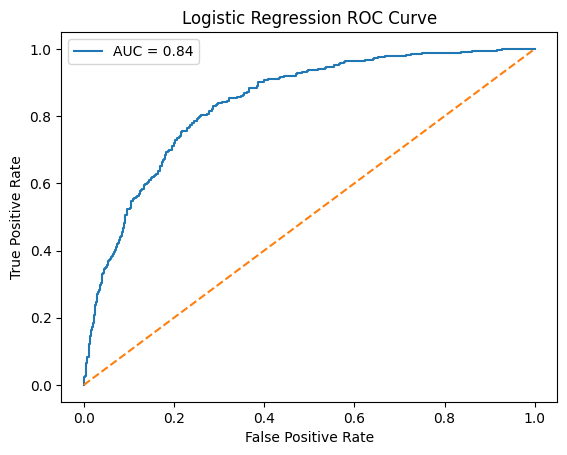

In [207]:
# Logistic Regression
lr = LogisticRegression(random_state=seed, class_weight='balanced')
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled) [:, 1]



#Model evaluation
lr_train_accuracy = accuracy_score(y_train, lr.predict(X_train_scaled))
lr_test_accuracy = accuracy_score(y_test, lr_pred)
lr_pres = precision_score(y_test, lr_pred)
lr_rec = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_prob)
lr_conf = confusion_matrix(y_test, lr_pred)



print('______________Logistic Regression Evaluation_________')

print(f'Train Accuracy: {lr_train_accuracy}')


print("Test Accuracy:", lr_test_accuracy)
print(f'Precision: {lr_pres}')
print(f'Recall: {lr_rec}')
print(f'F1 : {lr_f1}')
print(f'AUC: {lr_auc}')
print(f"Confusion Matrix:\n {lr_conf}")
#print("\nClassification Report:\n", classification_report(y_test, lr_pred))


# Plot ROC curve
fpr, tpr, threshold = roc_curve(y_test, lr_prob)
plt.plot(fpr, tpr, label=f"AUC = {lr_auc:.2f}")  
plt.plot([0,1], [0,1], linestyle='--')           
plt.title('Logistic Regression ROC Curve')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend()                                     
plt.show()



Best parameters: {'max_depth': np.int64(4), 'min_samples_leaf': np.int64(1), 'min_samples_split': np.int64(2)}
Best cross-validation score: 0.6251349325454432
____________  DecisionTree Evaluation___________

Train Accuracy: 0.7653333333333333
Test Accuracy: 0.7455579246624022
Precision: 0.5148148148148148
Recall: 0.7433155080213903
F1: 0.6083150984682714
AUC: 0.8208672626843573
Confusion Matrix:
 [[771 262]
 [ 96 278]]
 Fpr: [0.         0.00484027 0.06582769 0.11616651 0.22168441 0.2536302
 0.28944821 0.34365924 0.36011617 0.48499516 0.53533398 0.57308809
 0.58470474 0.73475315 0.77347531 1.        ]
Tpr: [0.         0.09358289 0.37165775 0.50802139 0.70320856 0.74331551
 0.78074866 0.8315508  0.85294118 0.9171123  0.94117647 0.95187166
 0.95454545 0.98128342 0.98663102 1.        ]
Threshold: [       inf 0.94593454 0.83387158 0.73422222 0.69292484 0.53400446
 0.49064174 0.45391217 0.4453042  0.31691111 0.29824878 0.27869157
 0.14530102 0.10985503 0.08182268 0.0221424 ]


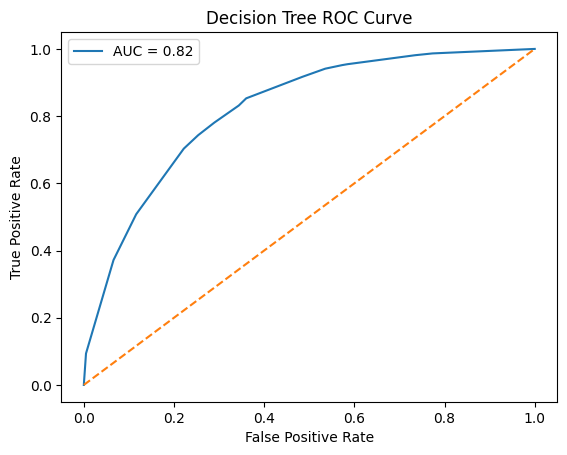

In [208]:
# decision tree

from sklearn.model_selection import GridSearchCV

kf= KFold(n_splits= 5, shuffle=True, random_state=seed)
dt = DecisionTreeClassifier(random_state= seed, class_weight='balanced')
param_grid = {
    'max_depth': np.arange(1, 11),
    'min_samples_split': np.arange(2, 11),
    'min_samples_leaf': np.arange(1,6)
}
dt_grid = GridSearchCV(estimator= dt, param_grid= param_grid, cv=kf, n_jobs=-1, scoring='f1')
dt_grid.fit(X_train, y_train)
print(f'Best parameters: {dt_grid.best_params_}')
print(f'Best cross-validation score: {dt_grid.best_score_}')



# Train and predict with the best parameters
dt = dt_grid.best_estimator_
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
dt_prob = dt.predict_proba(X_test)[:, 1]


#Model evaluation
dt_train_accuracy = accuracy_score(y_train, dt.predict(X_train))
dt_test_accuracy = accuracy_score(y_test, dt_pred)
df_pres = precision_score(y_test, dt_pred)
dt_rec = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)
dt_auc = roc_auc_score(y_test, dt_prob)
dt_conf = confusion_matrix(y_test, dt_pred)

print('____________  DecisionTree Evaluation___________')
print(f'\nTrain Accuracy: {dt_train_accuracy}')
print(f'Test Accuracy: {dt_test_accuracy}')
print(f'Precision: {df_pres}')
print(f'Recall: {dt_rec}')
print(f'F1: {dt_f1}')
print(f'AUC: {dt_auc}')
print(f"Confusion Matrix:\n {dt_conf}")

fpr, tpr, threshold = roc_curve(y_test, dt_prob)
print(f' Fpr: {fpr}\nTpr: {tpr}\nThreshold: {threshold}')



# Plot ROC curve

fpr, tpr, threshold = roc_curve(y_test, dt_prob)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, dt_prob):.2f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.title('Decision Tree ROC Curve')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend()

plt.show()


Best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best cross-validation score: 0.6354461538326459
____________  Random FOrest Evaluation___________

Train Accuracy: 0.8551111111111112
Test Accuracy: 0.7690120824449183
Precision: 0.5507246376811594
Recall: 0.7112299465240641
F1: 0.6207701283547258
AUC: 0.8319312940348188
Confusion Matrix:
 [[816 217]
 [108 266]]
 Fpr: [0.00000000e+00 0.00000000e+00 9.68054211e-04 9.68054211e-04
 1.93610842e-03 1.93610842e-03 2.90416263e-03 2.90416263e-03
 3.87221684e-03 3.87221684e-03 4.84027106e-03 4.84027106e-03
 5.80832527e-03 5.80832527e-03 1.06485963e-02 1.06485963e-02
 1.16166505e-02 1.16166505e-02 1.25847047e-02 1.25847047e-02
 1.54888674e-02 1.54888674e-02 1.64569216e-02 1.64569216e-02
 2.03291384e-02 2.03291384e-02 2.12971926e-02 2.12971926e-02
 2.22652469e-02 2.22652469e-02 2.32333011e-02 2.32333011e-02
 2.42013553e-02 2.42013553e-02 2.51694095e-02 2.51694095e-02
 2.71055179e-02 2.71055179e-

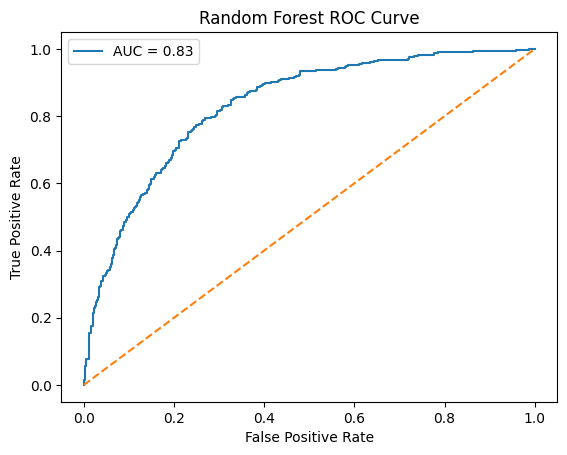

In [209]:
# RandomForest
rf = RandomForestClassifier(random_state= seed,class_weight='balanced')

params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
kf= KFold(n_splits= 5, shuffle=True, random_state=seed)
cv_rf = GridSearchCV(estimator= rf, param_grid= params, cv=kf, n_jobs=-1, scoring='f1')
cv_rf.fit(X_train, y_train)



print(f'Best parameters: {cv_rf.best_params_}')
print(f'Best cross-validation score: {cv_rf.best_score_}')



# Train and predict with the best parameters
rf = cv_rf.best_estimator_
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

#Model evaluation
rf_train_accuracy = accuracy_score(y_train, rf.predict(X_train))
rf_test_accuracy = accuracy_score(y_test, rf_pred)
rf_pres = precision_score(y_test, rf_pred)
rf_rec = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)
rf_conf = confusion_matrix(y_test, rf_pred)



print('____________  Random FOrest Evaluation___________')
print(f'\nTrain Accuracy: {rf_train_accuracy}')
print(f'Test Accuracy: {rf_test_accuracy}')
print(f'Precision: {rf_pres}')
print(f'Recall: {rf_rec}')
print(f'F1: {rf_f1}')
print(f'AUC: {rf_auc}')
print(f"Confusion Matrix:\n {rf_conf}")


fpr, tpr, threshold = roc_curve(y_test, rf_prob)
print(f' Fpr: {fpr}\nTpr: {tpr}\nThreshold: {threshold}')



# Plot ROC curve

fpr, tpr, threshold = roc_curve(y_test, rf_prob)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, rf_prob):.2f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.title('Random Forest ROC Curve')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend()

plt.show()


* Feature Impotance

In [210]:
X_test.columns

Index(['tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Female',
       'gender_Male', 'SeniorCitizen_0', 'SeniorCitizen_1', 'Partner_No',
       'Partner_Yes', 'Dependents_No', 'Dependents_Yes', 'PhoneService_No',
       'PhoneService_Yes', 'MultipleLines_No',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No', 'StreamingMovies_No internet service',
       'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_One year',
       '

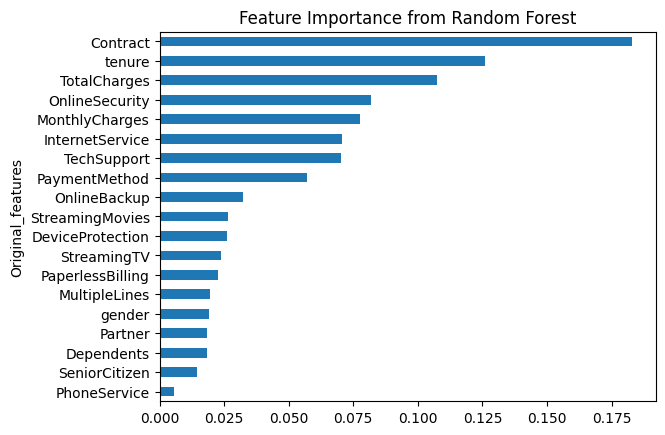

In [211]:
# Extract the features and importance
importances = rf.feature_importances_
features = X_train.columns


importance_df = pd.DataFrame({
    "Feature" : features,
    "Importance" : importances}).sort_values(by='Importance', ascending=False)


importance_df['Original_features'] = importance_df['Feature'].apply(lambda x: x.split('_')[0])
grouped = importance_df.groupby('Original_features')['Importance'].sum().sort_values(ascending= True)

grouped.plot(kind='barh')
plt.title('Feature Importance from Random Forest')
plt.show()


## Step5: Result

In [212]:
model_info = {'Model': ['KNN', 'Logistic Regression', 'Decision Tree', 'Random Forest'],
        'Train Accuracy': [knn_train_accuracy, lr_train_accuracy, dt_train_accuracy, rf_train_accuracy],
        'Test Accuracy': [knn_test_accuracy, lr_test_accuracy, dt_test_accuracy, rf_test_accuracy],
        'Precision' : [knn_pres, lr_pres, df_pres, rf_pres],
        'Recall': [knn_rec, lr_rec, dt_rec, rf_rec],
        'F1 Score': [knn_f1, lr_f1, dt_f1, rf_f1],
        'AUC': [knn_auc, lr_auc, dt_auc, rf_auc]}

In [213]:
df = pd.DataFrame(model_info)
df

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,AUC
0,KNN,0.802489,0.772566,0.578035,0.534759,0.555556,0.804902
1,Logistic Regression,0.749867,0.754087,0.524476,0.802139,0.634249,0.840098
2,Decision Tree,0.765333,0.745558,0.514815,0.743316,0.608315,0.820867
3,Random Forest,0.855111,0.769012,0.550725,0.711230,0.620770,0.831931


> Best model

* Logistic Regression was selected as the best model, as it achieved  the strongest overall performance, achieving the highest AUC-ROC of 0.840 and the highest Recall of 0.802, meaning it correctly identified approximately 80% of customers who actually churned. Although its precision is comparatively low (0.524) this trade-off is acceptable given the business objective of maximising churn detection. Lastly, its train and test accuracy were also closely aligned (0.750 vs 0.754), indicating that the model generalises well without overfitting.



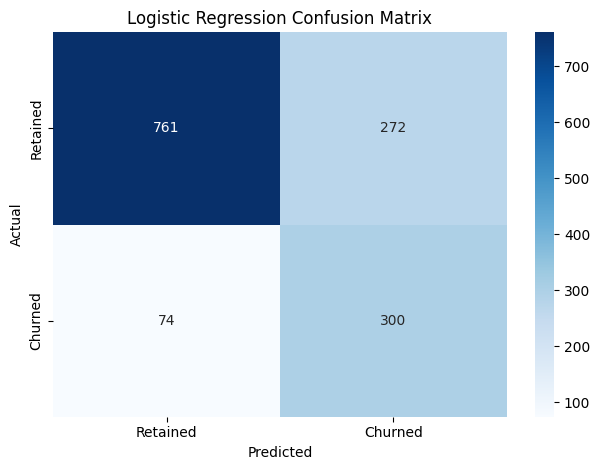

In [214]:
# logistic regression confusion matrix

sns.heatmap(lr_conf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Retained','Churned'], yticklabels=['Retained','Churned'])
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Conclusion and Recommendation

> Key Finding
* Customers on month-to-month contracts exhibit the highest churn rate than customers in the other contract types, suggesting that lack of commitment increases likelihood of leaving.

* Revenue metrics (like TotalCharges and MonthlyCharges) influence churn rate. Customers with higher monthly charges (especially relative to value) are more likely to churn. Indicating potential dissatisfaction with pricing or perceived value.

* Short-tenure customers are significantly more likely to churn, highlighting the importance of early customer retention.

* Fiber optic customers are at the highest risk of churners. This possibly due to dissatisfaction with cost, service expectations.

* Customers paying via electronic check demonstrate higher churn,which may reflect differences in customer engagement or payment convenience.


> Recommendation
* Customers on month-to-month contracts should be engaged to switch to long-term plans by offering incentives such as discounts or bonus benefits, as this will help reduce churn.
* Value offered to high-paying customers should be improved by enhancing service quality or providing additional benefits, since customers paying higher charges are more likely to churn if they feel the service is not worth the cost.
* Implementation of strong onboarding programs and early engagement strategies for new customers, as customers with shorter tenure are at a higher risk of leaving.
* Investigation and improvement of fiber optic service experience, pricing and service quality, because customers using this service have a higher likelihood of churning.
* Encourage customers to switch from electronic check to more automated payment methods, such as bank transfers or card payments, to increase customer retention and reduce churn.
* Deploy the trained model in the Customer Relationship (CRM) system to generate weekly churn scores, enabling the retention team to prioritise outreach efficiently.
